In [7]:
GLOBAL_CLEAN_AUDIO = "lab3sample.wav"
#GLOBAL_CLEAN_AUDIO = "my_recorded_clean.wav"
GLOBAL_NOISY_AUDIO = "my_recorded_noisy.wav"

In [3]:
# Check file exists & play (uses GLOBAL_CLEAN_AUDIO)
import os
from IPython.display import Audio, display

if not os.path.exists(GLOBAL_CLEAN_AUDIO):
    raise FileNotFoundError(f"⚠️ Audio file not found: {GLOBAL_CLEAN_AUDIO}\nPlease check the path.")
else:
    print(f"🎧 Using audio file: {GLOBAL_CLEAN_AUDIO}")

print("Playing the best reconstructed signal:")
display(Audio(GLOBAL_CLEAN_AUDIO))


🎧 Using audio file: lab3sample.wav
Playing the best reconstructed signal:


In [109]:
# Record helper for clean audio (optional)
import sounddevice as sd
import soundfile as sf

def record(filename="mic.wav", duration=4, sr=16000):
    print("🎙️ Speak now...")
    rec = sd.rec(int(duration * sr), samplerate=sr, channels=1)
    sd.wait()
    sf.write(filename, rec, sr)
    print(f"✅ Saved recording as: {filename}")

record("my_recorded_clean.wav", duration=4)
GLOBAL_CLEAN_AUDIO = "my_recorded_clean.wav"
display(Audio(GLOBAL_CLEAN_AUDIO))


🎙️ Speak now...
✅ Saved recording as: my_recorded_clean.wav


In [8]:
# Record helper for noisy audio (optional)
import sounddevice as sd
import soundfile as sf

def record(filename="mic.wav", duration=4, sr=16000):
    print("🎙️ Speak now...")
    rec = sd.rec(int(duration * sr), samplerate=sr, channels=1)
    sd.wait()
    sf.write(filename, rec, sr)
    print(f"✅ Saved recording as: {filename}")

record("my_recorded_noisy.wav", duration=4)
GLOBAL_NOISY_AUDIO = "my_recorded_noisy.wav"
display(Audio(GLOBAL_NOISY_AUDIO))


🎙️ Speak now...


KeyboardInterrupt: 

In [5]:
display(Audio(GLOBAL_CLEAN_AUDIO))
display(Audio(GLOBAL_NOISY_AUDIO))

In [9]:
# Add noise (creates GLOBAL_NOISY_AUDIO from GLOBAL_CLEAN_AUDIO)
import numpy as np
import soundfile as sf

def add_noise(input_file, output_file, noise_factor=0.02):
    y, sr = sf.read(input_file)
    # if stereo, convert to mono by taking mean across channels
    if y.ndim > 1:
        y = np.mean(y, axis=1)
    noise = np.random.randn(len(y))
    y_noisy = y + noise_factor * noise
    y_noisy = np.clip(y_noisy, -1.0, 1.0)
    sf.write(output_file, y_noisy, sr)
    print(f"✅ Noisy version saved as: {output_file}")

# Create noisy file from the global clean file (only call once)
add_noise(GLOBAL_CLEAN_AUDIO, GLOBAL_NOISY_AUDIO, noise_factor=0.02)
display(Audio(GLOBAL_NOISY_AUDIO))


✅ Noisy version saved as: my_recorded_noisy.wav


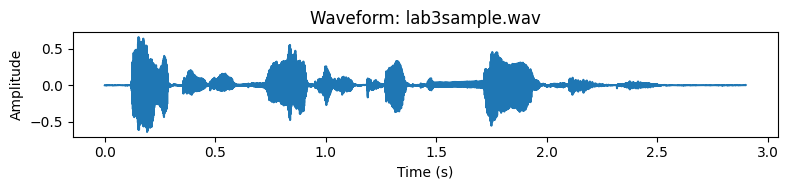

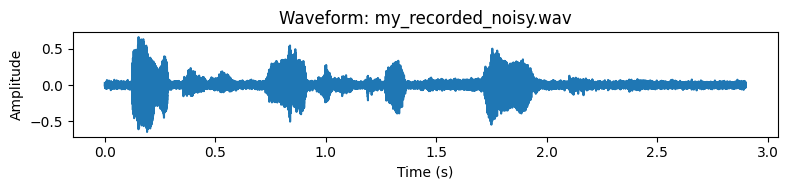

In [10]:
# Plot waveforms (works for both globals)
import librosa
import matplotlib.pyplot as plt

def plot_waveform(path, figsize=(8,2)):
    y, sr = librosa.load(path, sr=None, mono=True)
    t = np.arange(len(y)) / sr
    plt.figure(figsize=figsize)
    plt.plot(t, y)
    plt.title(f"Waveform: {path}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# Plot both
plot_waveform(GLOBAL_CLEAN_AUDIO)
plot_waveform(GLOBAL_NOISY_AUDIO)


In [11]:
# Whisper transcription (loads model once)
import whisper

try:
    print("Loading Whisper model (base)...")
    whisper_model = whisper.load_model("base")
    print("✅ Whisper model loaded successfully.")
except Exception as e:
    whisper_model = None
    print(f"❌ Error loading Whisper model: {e}")

def transcribe_with_whisper(file_path):
    if whisper_model is None:
        print("❌ Whisper model not loaded.")
        return ""
    print(f"🎧 Recognizing with Whisper: {file_path}")
    try:
        result = whisper_model.transcribe(file_path)
        text = result.get("text", "").strip()
        if text:
            print("✅ Whisper transcription successful!")
        else:
            print("⚠️ Whisper could not understand the audio.")
        return text
    except Exception as e:
        print(f"❌ Error in Whisper transcription: {e}")
        return ""


Loading Whisper model (base)...
✅ Whisper model loaded successfully.


In [12]:
# Google SpeechRecognition transcription
import speech_recognition as sr

recognizer = sr.Recognizer()

def transcribe_with_google(file_path):
    print(f"🌐 Recognizing with Google Speech API: {file_path}")
    try:
        with sr.AudioFile(file_path) as source:
            audio = recognizer.record(source)
        text = recognizer.recognize_google(audio)
        print("✅ Google transcription successful!")
        return text
    except sr.UnknownValueError:
        print("⚠️ Google could not understand audio.")
        return ""
    except sr.RequestError:
        print("❌ Google API request failed. Check internet connection.")
        return ""
    except Exception as e:
        print(f"❌ Error during Google transcription: {e}")
        return ""


In [13]:

import warnings
warnings.filterwarnings("ignore")
# Transcribe both files (use the globals)
# Clean speech transcriptions
whisper_clean = transcribe_with_whisper(GLOBAL_CLEAN_AUDIO)
google_clean  = transcribe_with_google(GLOBAL_CLEAN_AUDIO)

# Noisy speech transcriptions
whisper_noisy = transcribe_with_whisper(GLOBAL_NOISY_AUDIO)
google_noisy  = transcribe_with_google(GLOBAL_NOISY_AUDIO)


🎧 Recognizing with Whisper: lab3sample.wav
✅ Whisper transcription successful!
🌐 Recognizing with Google Speech API: lab3sample.wav
✅ Google transcription successful!
🎧 Recognizing with Whisper: my_recorded_noisy.wav
✅ Whisper transcription successful!
🌐 Recognizing with Google Speech API: my_recorded_noisy.wav
✅ Google transcription successful!


In [14]:
# Compare function & print results
def compare_transcripts(whisper_text, google_text, label="Audio"):
    print(f"\n======= SPEECH-TO-TEXT COMPARISON ({label}) =======")
    print(f"Whisper: {whisper_text if whisper_text else '[No output]'}")
    print(f"Google:  {google_text if google_text else '[No output]'}")
    print("===============================================")

compare_transcripts(whisper_clean, google_clean, label="CLEAN")
compare_transcripts(whisper_noisy, google_noisy, label="NOISY")



======= SPEECH-TO-TEXT COMPARISON (CLEAN) =======
Whisper: I believe you're just talking nonsense.
Google:  I believe you are just talking nonsense

======= SPEECH-TO-TEXT COMPARISON (NOISY) =======
Whisper: I believe you're just talking nonsense.
Google:  I believe you are just talking nonsense


In [15]:
# TF-IDF similarity analysis (uses transcripts above)
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def compute_tfidf_similarity(transcripts, names, reference_text, show_heatmap=True, cmap='viridis'):
    corpus = [reference_text] + transcripts
    labels = ["GroundTruth"] + names

    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    sim_matrix = cosine_similarity(X)
    df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

    print("\nTF-IDF Cosine Similarity Matrix:")
    print(df.round(4))

    if show_heatmap:
        plt.figure(figsize=(6,5))
        im = plt.imshow(sim_matrix, vmin=0, vmax=1, cmap=cmap)
        plt.title("TF-IDF Cosine Similarity")
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(sim_matrix.shape[0]):
            for j in range(sim_matrix.shape[1]):
                plt.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                         fontsize=9, color='white' if sim_matrix[i,j] < 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    return sim_matrix, df



TF-IDF Cosine Similarity Matrix:
                 GroundTruth  Whisper (Clean)  Google (Clean)  \
GroundTruth            1.000            0.675           1.000   
Whisper (Clean)        0.675            1.000           0.675   
Google (Clean)         1.000            0.675           1.000   
Whisper (Noisy)        0.675            1.000           0.675   
Google (Noisy)         1.000            0.675           1.000   

                 Whisper (Noisy)  Google (Noisy)  
GroundTruth                0.675           1.000  
Whisper (Clean)            1.000           0.675  
Google (Clean)             0.675           1.000  
Whisper (Noisy)            1.000           0.675  
Google (Noisy)             0.675           1.000  


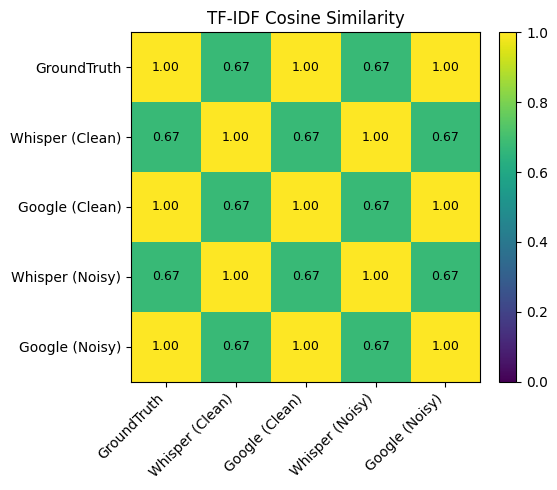

In [16]:
reference_text = input("👉 Enter the exact ground-truth/reference text: ")

sim_matrix, sim_df = compute_tfidf_similarity(
    transcripts=[whisper_clean, google_clean, whisper_noisy, google_noisy],
    names=["Whisper (Clean)", "Google (Clean)", "Whisper (Noisy)", "Google (Noisy)"],
    reference_text=reference_text,
    show_heatmap=True
)